In [1]:
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 200)

<h4> Download Subsets and save original parquets -> C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet

In [2]:
from datasets import load_dataset

# ── Set your save location here ──────────────────────────────
SAVE_PATH = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet"

# ─────────────────────────────────────────────────────────────

import os
os.makedirs(SAVE_PATH, exist_ok=True)  # creates folder if it doesn't exist

subsets = ["human_pull_request", "human_pr_task_type"]

for subset in subsets:
    print(f"Downloading {subset}...")
    ds = load_dataset("hao-li/AIDev", subset)

    save_file = os.path.join(SAVE_PATH, f"{subset}.parquet")
    ds["train"].to_parquet(save_file)

    print(f"Saved {subset} — {len(ds['train'])} rows")
    print(f"Location: {save_file}\n")

c:\SID\Anaconda3\envs\apoorva_ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 10.96ba/s]


Saved human_pull_request — 6618 rows
Location: C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\human_pull_request.parquet



Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 53.92ba/s]

Saved human_pr_task_type — 6618 rows
Location: C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\human_pr_task_type.parquet



<h4> Join the 2 datasets -> human_pull_request + human_pr_task_type

In [3]:
# ── Load both parquets ────────────────────────────────────────
pr   = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\human_pull_request.parquet")
task = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\human_pr_task_type.parquet")

# ── Join on id — bring only type from task (confidence is all NaN) ────
df = pr.merge(task[['id', 'type']], on='id', how='inner')

# ── Verify ────────────────────────────────────────────────────
print(f"PR dataset:      {pr.shape}")
print(f"Task dataset:    {task.shape}")
print(f"Joined dataset:  {df.shape}")
print(f"\nColumns in joined df:\n{df.columns.tolist()}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nSample:")
print(df[['id', 'title', 'user', 'state', 'type']].head(5).to_string())

# ── Save joined parquet ───────────────────────────────────────
SAVE_PATH = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet"
os.makedirs(SAVE_PATH, exist_ok=True)

save_file = os.path.join(SAVE_PATH, "joined_dataset.parquet")
df.to_parquet(save_file, index=False)

print(f"\nJoined dataset saved to: {save_file}")

PR dataset:      (6618, 13)
Task dataset:    (6618, 6)
Joined dataset:  (6618, 14)

Columns in joined df:
['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent', 'type']

Null counts:
id               0
number           0
title            0
user             0
user_id          0
state            0
created_at       0
closed_at      469
merged_at     1537
repo_url         0
html_url         0
body           995
agent            0
type             0
dtype: int64

Sample:
           id                                                                   title           user   state      type
0  2336888723                                   feat(aci): add automations index page      ameliahsu  closed      feat
1  2447123365   ref(insights): Make use of `<FeatureBadge>` for new Insight page tabs        ryan953  closed  refactor
2  2438086945  :bug: fix: update how we fetch workflow_id and legacy_rule_id from ru…    iam

<h4> Create new column dev_time_hrs -> development time

In [4]:
import pandas as pd
import numpy as np

# ── Load the joined parquet ───────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\joined_dataset.parquet")

# ── Parse timestamps ──────────────────────────────────────────────
df['created_at'] = pd.to_datetime(df['created_at'])
df['closed_at']  = pd.to_datetime(df['closed_at'])
df['merged_at']  = pd.to_datetime(df['merged_at'])

# ── Calculate development time ────────────────────────────────────
# | closed_at - created_at | in hours
df['dev_time_hrs'] = (
    df['closed_at'] - df['created_at']
).dt.total_seconds() / 3600

# Take absolute value just in case any timestamps are flipped
# df['dev_time_hrs'] = df['dev_time_hrs'].abs()

# ── Quick sanity check ────────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"Null dev_time_hrs: {df['dev_time_hrs'].isna().sum()}")
print(f"\nDev time summary (hours):")
print(df['dev_time_hrs'].describe())

# ── Save back to parquet ──────────────────────────────────────────
df.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\dev_time_col_dataset.parquet", index=False)
print("\nSaved successfully!")

Total rows: 6618
Null dev_time_hrs: 469

Dev time summary (hours):
count    6149.000000
mean       92.971668
std       284.567963
min         0.000278
25%         0.473056
50%         5.363333
75%        49.029722
max      3815.923333
Name: dev_time_hrs, dtype: float64

Saved successfully!


<h4> graph of the data in dev_time_hrs check skewness and make box plot

In [5]:
import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Load your parquet ─────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\dev_time_col_dataset.parquet")

# ── Drop nulls for plotting ───────────────────────────────────────
dev_time = df['dev_time_hrs'].dropna()

# ── Check Skewness ────────────────────────────────────────────────
skewness = dev_time.skew()
print(f"Skewness: {skewness:.2f}")
print("Interpretation:", end=" ")
if skewness > 1:
    print("Highly right skewed")
elif skewness > 0.5:
    print("Moderately right skewed")
else:
    print("Roughly symmetric")

# ── Interactive Plot: 2 charts side by side ───────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Histogram (Raw)', 'Box Plot (Raw)')
)

# Chart 1 — Histogram
fig.add_trace(
    go.Histogram(
        x=dev_time,
        nbinsx=200,
        marker_color='steelblue',
        marker_line_color='white',
        marker_line_width=0.5,
        name='dev_time_hrs',
        hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# Chart 2 — Box plot
fig.add_trace(
    go.Box(
        y=dev_time,
        marker_color='steelblue',
        fillcolor='rgba(70,130,180,0.4)',
        name='dev_time_hrs',
        boxmean=True,
        hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
    ),
    row=1, col=2
)

# ── Layout ────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(text='dev_time_hrs Distribution Analysis', x=0.5, font=dict(size=16)),
    showlegend=False,
    height=500,
    width=1100,
    template='plotly_white'
)

fig.update_xaxes(title_text='dev_time_hrs', row=1, col=1)
fig.update_yaxes(title_text='Count',        row=1, col=1)
fig.update_yaxes(title_text='dev_time_hrs', row=1, col=2)

pio.renderers.default = 'browser'
fig.show()
fig.write_html('dev_time_distribution.html')
print("Interactive plot saved as dev_time_distribution.html!")

Skewness: 5.93
Interpretation: Highly right skewed
Interactive plot saved as dev_time_distribution.html!


<h4> dropping open PRs from dataset and keeping in a separate parquet file -> open_prs_dataset.parquet, our filtererd dataset is now -> closed_prs_dataset

In [6]:
import pandas as pd

# ── Load your parquet ─────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\dev_time_col_dataset.parquet")

print(f"Total rows before: {len(df)}")
print(f"Open PRs (null closed_at): {df['closed_at'].isna().sum()}")

# ── Separate open and closed PRs ──────────────────────────────────
df_closed = df[df['closed_at'].notna()]   # PRs that are closed
df_open   = df[df['closed_at'].isna()]    # PRs that are still open

print(f"\nClosed PRs: {len(df_closed)}")
print(f"Open PRs:   {len(df_open)}")

# ── Save closed PRs (main dataset going forward) ──────────────────
df_closed.to_parquet('C:\\SID\\Apoorva\\Project\\504_Project_AI_for_SW\\dataset_parquet\\closed_prs_dataset.parquet', index=False)
print("\nSaved closed PRs to closed_prs_dataset.parquet!")

# ── Save open PRs separately (for reference) ──────────────────────
df_open.to_parquet('C:\\SID\\Apoorva\\Project\\504_Project_AI_for_SW\\dataset_parquet\\open_prs_dataset.parquet', index=False)
print("Saved open PRs to open_prs_dataset.parquet!")

Total rows before: 6618
Open PRs (null closed_at): 469

Closed PRs: 6149
Open PRs:   469

Saved closed PRs to closed_prs_dataset.parquet!
Saved open PRs to open_prs_dataset.parquet!


In [7]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

# ── Load your parquet ─────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\closed_prs_dataset.parquet")

dev_time = df['dev_time_hrs'].dropna()

# ── Check Skewness ────────────────────────────────────────────────
skewness = dev_time.skew()
print(f"Total rows: {len(df)}")
print(f"Skewness: {skewness:.2f}")
print("Interpretation:", end=" ")
if skewness > 1:
    print("Highly right skewed")
elif skewness > 0.5:
    print("Moderately right skewed")
else:
    print("Roughly symmetric")

# ── Interactive Plot ───────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Histogram (Raw)', 'Box Plot (Raw)')
)

# Chart 1 — Histogram
fig.add_trace(
    go.Histogram(
        x=dev_time,
        nbinsx=200,
        marker_color='steelblue',
        marker_line_color='white',
        marker_line_width=0.5,
        name='dev_time_hrs',
        hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# Chart 2 — Box plot
fig.add_trace(
    go.Box(
        y=dev_time,
        marker_color='steelblue',
        fillcolor='rgba(70,130,180,0.4)',
        name='dev_time_hrs',
        boxmean=True,
        hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(text='dev_time_hrs Distribution Analysis (Closed PRs only)', x=0.5, font=dict(size=16)),
    showlegend=False,
    height=500,
    width=1100,
    template='plotly_white'
)

fig.update_xaxes(title_text='dev_time_hrs', row=1, col=1)
fig.update_yaxes(title_text='Count',        row=1, col=1)
fig.update_yaxes(title_text='dev_time_hrs', row=1, col=2)

fig.show()
fig.write_html('dev_time_closed_prs.html')
print("\nPlot saved as dev_time_closed_prs.html!")

Total rows: 6149
Skewness: 5.93
Interpretation: Highly right skewed

Plot saved as dev_time_closed_prs.html!


In [8]:
import pandas as pd

# ── Load both parquets ────────────────────────────────────────────
df_original = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\dev_time_col_dataset.parquet")
df_closed   = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\closed_prs_dataset.parquet")

# ── Calculate ─────────────────────────────────────────────────────
total   = len(df_original)
kept    = len(df_closed)
dropped = total - kept

print(f"Original rows : {total}")
print(f"Kept (closed) : {kept}")
print(f"Dropped (open): {dropped}")
print(f"% Dropped     : {dropped/total*100:.2f}%")
print(f"% Kept        : {kept/total*100:.2f}%")

Original rows : 6618
Kept (closed) : 6149
Dropped (open): 469
% Dropped     : 7.09%
% Kept        : 92.91%


<h4> Code to drop the PRs which were closed in less than or equal to 1 minute time in closed_prs_dataset.parquet, **changed to drop PRs with 5min or less.

In [9]:
import pandas as pd

# ── Load the parquet ──────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\closed_prs_dataset.parquet")

print(f"Rows before: {len(df)}")

# ── Separate the two groups ───────────────────────────────────────
df_cleaned = df[df['dev_time_hrs'] >  5/60]   # keep these (more than 5 minutes)
df_dropped = df[df['dev_time_hrs'] <= 5/60]   # dropped rows (5 minutes or less)

print(f"Rows kept:    {len(df_cleaned)}")
print(f"Rows dropped: {len(df_dropped)}")

# ── Save both ─────────────────────────────────────────────────────
df_cleaned.to_parquet('C:\\SID\\Apoorva\\Project\\504_Project_AI_for_SW\\dataset_parquet\\instant_close_drop_prs_clean_dataset.parquet', index=False)
print("Saved cleaned to instant_close_drop_prs_clean_dataset.parquet!")

df_dropped.to_parquet('C:\\SID\\Apoorva\\Project\\504_Project_AI_for_SW\\dataset_parquet\\instant_close_prs.parquet', index=False)
print("Saved dropped rows to instant_close_prs.parquet!")

Rows before: 6149
Rows kept:    5464
Rows dropped: 685
Saved cleaned to instant_close_drop_prs_clean_dataset.parquet!
Saved dropped rows to instant_close_prs.parquet!


In [10]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\instant_close_drop_prs_clean_dataset.parquet")

dev_time = df['dev_time_hrs']

# ── Skewness ──────────────────────────────────────────────────────
skewness = dev_time.skew()
print(f"Total rows: {len(df)}")
print(f"Skewness:   {skewness:.2f}")

# ── Plot ──────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2, subplot_titles=('Histogram', 'Box Plot'))

fig.add_trace(go.Histogram(
    x=dev_time, nbinsx=200,
    marker_color='steelblue', marker_line_color='white', marker_line_width=0.5,
    hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Box(
    y=dev_time, marker_color='steelblue',
    fillcolor='rgba(70,130,180,0.4)', boxmean=True,
    hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title=dict(text='dev_time_hrs Distribution Analysis', x=0.5),
    showlegend=False, height=500, width=1100, template='plotly_white'
)

fig.update_xaxes(title_text='dev_time_hrs', row=1, col=1)
fig.update_yaxes(title_text='Count',        row=1, col=1)
fig.update_yaxes(title_text='dev_time_hrs', row=1, col=2)

fig.show()

Total rows: 5464
Skewness:   5.59


In [11]:
before = 6149
after  = 5823

dropped = before - after

print(f"Before  : {before}")
print(f"After   : {after}")
print(f"Dropped : {dropped}")
print(f"% Loss  : {dropped/before*100:.2f}%")
print(f"% Kept  : {after/before*100:.2f}%")

Before  : 6149
After   : 5823
Dropped : 326
% Loss  : 5.30%
% Kept  : 94.70%


<h4> now drop the users as bots

In [12]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\instant_close_drop_prs_clean_dataset.parquet")

print(f"Rows before: {len(df)}")

# ── Find bot users ────────────────────────────────────────────────
df_bots    = df[df['user'].str.contains(r'\[bot\]', na=False)]
df_cleaned = df[~df['user'].str.contains(r'\[bot\]', na=False)]

print(f"\nBot PRs found: {len(df_bots)}")
print(df_bots['user'].value_counts())

print(f"\nRows kept  : {len(df_cleaned)}")
print(f"Rows dropped: {len(df_bots)}")
print(f"% Loss     : {len(df_bots)/len(df)*100:.2f}%")

# ── Save both ─────────────────────────────────────────────────────
df_cleaned.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_bots_clean_dataset.parquet", index=False)
print("\nSaved cleaned to no_bots_clean_dataset.parquet!")

df_bots.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\bot_prs.parquet", index=False)
print("Saved bot rows to bot_prs.parquet!")

Rows before: 5464

Bot PRs found: 755
user
dependabot[bot]                    375
renovate[bot]                      158
github-actions[bot]                104
dotnet-maestro[bot]                 48
gru-agent[bot]                      21
devin-ai-integration[bot]           11
liam-changeset-ci-trigger[bot]       6
scala-steward-wvlet[bot]             5
resyntax-ci[bot]                     4
codeflash-ai[bot]                    4
dotnet-policy-service[bot]           3
rnuinoci[bot]                        3
octo-sts[bot]                        2
liam-license-ci-trigger[bot]         1
gcp-cherry-pick-bot[bot]             1
entelligence-ai-pr-reviews[bot]      1
dane-ai-mastra[bot]                  1
jenkins-dependency-updater[bot]      1
hash-worker[bot]                     1
mlflow-app[bot]                      1
primer[bot]                          1
pulumi-renovate[bot]                 1
co-op-translator[bot]                1
pre-commit-ci[bot]                   1
Name: count, dtype: i

In [13]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_bots_clean_dataset.parquet")

dev_time = df['dev_time_hrs']

# ── Skewness ──────────────────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"Skewness:   {dev_time.skew():.2f}")

# ── Plot ──────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2, subplot_titles=('Histogram', 'Box Plot'))

fig.add_trace(go.Histogram(
    x=dev_time, nbinsx=200,
    marker_color='steelblue', marker_line_color='white', marker_line_width=0.5,
    hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Box(
    y=dev_time, marker_color='steelblue',
    fillcolor='rgba(70,130,180,0.4)', boxmean=True,
    hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title=dict(text='dev_time_hrs Distribution (No Bots)', x=0.5),
    showlegend=False, height=500, width=1100, template='plotly_white'
)

fig.update_xaxes(title_text='dev_time_hrs', row=1, col=1)
fig.update_yaxes(title_text='Count',        row=1, col=1)
fig.update_yaxes(title_text='dev_time_hrs', row=1, col=2)

fig.show()

Total rows: 4709
Skewness:   5.60


<h4> See the Negative dev_time_hrs rows

In [14]:
import pandas as pd

df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_bots_clean_dataset.parquet")

negative = df[df['dev_time_hrs'] < 0]

print(f"Negative dev_time_hrs rows: {len(negative)}")
print(negative[['user', 'created_at', 'closed_at', 'dev_time_hrs']].head(10))

Negative dev_time_hrs rows: 0
Empty DataFrame
Columns: [user, created_at, closed_at, dev_time_hrs]
Index: []


<h4> Check for duplicates

In [15]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_bots_clean_dataset.parquet")

print(f"Total rows: {len(df)}")

# ── Check 1: Fully duplicate rows ─────────────────────────────────
full_dups = df[df.duplicated(keep=False)]
print(f"\nFully duplicate rows : {len(full_dups)}")

# ── Check 2: Duplicate titles ─────────────────────────────────────
title_dups = df[df['title'].duplicated(keep=False)]
print(f"Duplicate titles     : {len(title_dups)}")
print("\nTop duplicate titles:")
print(title_dups['title'].value_counts().head(10))

# ── Check 3: Duplicate PR ids ─────────────────────────────────────
id_dups = df[df['id'].duplicated(keep=False)]
print(f"\nDuplicate PR ids     : {len(id_dups)}")

Total rows: 4709

Fully duplicate rows : 0
Duplicate titles     : 112

Top duplicate titles:
title
feat: update translations via @lingodotdev              21
fix(i18n): update translations                          20
Update README.md                                         7
Update installation.mdx                                  6
Weekly `cargo update` of dependencies                    5
Update docs                                              3
chore(deps): update deno dependencies                    3
本番リリース                                                   3
🐛 Display Related Tables for Nodes without Relations     2
dev->main                                                2
Name: count, dtype: int64

Duplicate PR ids     : 0


<h4> Removed duplicates on the basis of user and title

In [16]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_bots_clean_dataset.parquet")

print(f"Rows before: {len(df)}")

# ── Drop duplicates on user and title ───────────────────────────────
df_cleaned   = df.drop_duplicates(subset=['user', 'title'], keep='first')
df_dropped   = df[df.duplicated(subset=['user', 'title'], keep='first')]

print(f"Rows kept    : {len(df_cleaned)}")
print(f"Rows dropped : {len(df_dropped)}")
print(f"% Loss       : {len(df_dropped)/len(df)*100:.2f}%")

# ── Save both ─────────────────────────────────────────────────────
df_cleaned.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_duplicates_user&_title_clean_dataset.parquet", index=False)
print("\nSaved cleaned to no_duplicates_user&_title_clean_dataset.parquet!")

df_dropped.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\duplicate_user&_title_prs.parquet", index=False)
print("Saved dropped to duplicate_user&_title_prs.parquet!")

Rows before: 4709
Rows kept    : 4645
Rows dropped : 64
% Loss       : 1.36%

Saved cleaned to no_duplicates_user&_title_clean_dataset.parquet!
Saved dropped to duplicate_user&_title_prs.parquet!


In [17]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_duplicates_user&_title_clean_dataset.parquet")

dev_time = df['dev_time_hrs']

# ── Skewness ──────────────────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"Skewness:   {dev_time.skew():.2f}")

# ── Plot ──────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2, subplot_titles=('Histogram', 'Box Plot'))

fig.add_trace(go.Histogram(
    x=dev_time, nbinsx=200,
    marker_color='steelblue', marker_line_color='white', marker_line_width=0.5,
    hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Box(
    y=dev_time, marker_color='steelblue',
    fillcolor='rgba(70,130,180,0.4)', boxmean=True,
    hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title=dict(text='dev_time_hrs Distribution (No Duplicates)', x=0.5),
    showlegend=False, height=500, width=1100, template='plotly_white'
)

fig.update_xaxes(title_text='dev_time_hrs', row=1, col=1)
fig.update_yaxes(title_text='Count',        row=1, col=1)
fig.update_yaxes(title_text='dev_time_hrs', row=1, col=2)

fig.show()

Total rows: 4645
Skewness:   5.57


<h4> Code to create separate datasets on the basis of each type

In [18]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\no_duplicates_user&_title_clean_dataset.parquet")

print(f"Total rows: {len(df)}")
print(f"\nRows per type:")
print(df['type'].value_counts())

# ── Save each type as a separate parquet ──────────────────────────
base_path = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type"

for task_type in df['type'].unique():
    df_type = df[df['type'] == task_type]
    save_path = f"{base_path}\\{task_type}_prs.parquet"
    df_type.to_parquet(save_path, index=False)
    print(f"Saved {task_type:10} — {len(df_type):>4} rows  →  {task_type}_prs.parquet")

Total rows: 4645

Rows per type:
type
feat        1561
fix         1368
chore        411
docs         364
refactor     308
build        248
test         139
ci            79
perf          62
other         57
style         48
Name: count, dtype: int64
Saved feat       — 1561 rows  →  feat_prs.parquet
Saved refactor   —  308 rows  →  refactor_prs.parquet
Saved fix        — 1368 rows  →  fix_prs.parquet
Saved perf       —   62 rows  →  perf_prs.parquet
Saved chore      —  411 rows  →  chore_prs.parquet
Saved build      —  248 rows  →  build_prs.parquet
Saved style      —   48 rows  →  style_prs.parquet
Saved ci         —   79 rows  →  ci_prs.parquet
Saved docs       —  364 rows  →  docs_prs.parquet
Saved test       —  139 rows  →  test_prs.parquet
Saved other      —   57 rows  →  other_prs.parquet


<h4> See the distribution of dev_time_hrs for all of these created datasets on the basis of type

In [19]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import os

pio.renderers.default = 'browser'

# ── Load all type datasets ────────────────────────────────────────
base_path = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type"

types = ['feat', 'fix', 'chore', 'docs', 'refactor', 
         'build', 'test', 'ci', 'other', 'perf', 'style']

# ── Plot: one row per type, histogram + box plot ──────────────────
fig = make_subplots(
    rows=len(types), cols=2,
    subplot_titles=[f"{t} — Histogram" if i%2==0 
                    else f"{t} — Box Plot" 
                    for t in types for i in range(2)],
    vertical_spacing=0.03
)

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'darkorange',
          'crimson', 'teal', 'goldenrod', 'slategray', 'hotpink', 'peru']

for i, task_type in enumerate(types):
    path = os.path.join(base_path, f"{task_type}_prs.parquet")
    
    # skip if file does not exist
    if not os.path.exists(path):
        print(f"Skipping {task_type} — file not found")
        continue

    df   = pd.read_parquet(path)
    data = df['dev_time_hrs'].dropna()
    row  = i + 1
    col  = colors[i]

    print(f"{task_type:10} — rows: {len(data):>4}  median: {data.median():.2f} hrs  skew: {data.skew():.2f}")

    # Histogram
    fig.add_trace(go.Histogram(
        x=data, nbinsx=50,
        marker_color=col, marker_line_color='white', marker_line_width=0.3,
        name=task_type,
        hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
    ), row=row, col=1)

    # Box plot
    fig.add_trace(go.Box(
        y=data,
        marker_color=col,
        fillcolor=col,
        opacity=0.5,
        name=task_type,
        boxmean=True,
        hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
    ), row=row, col=2)

# ── Layout ────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(text='dev_time_hrs Distribution by Task Type', x=0.5, font=dict(size=16)),
    showlegend=False,
    height=400 * len(types),
    width=1100,
    template='plotly_white'
)

fig.show()
fig.write_html('dev_time_by_type.html')
print("\nSaved as dev_time_by_type.html!")

feat       — rows: 1561  median: 20.95 hrs  skew: 4.78
fix        — rows: 1368  median: 7.46 hrs  skew: 6.12
chore      — rows:  411  median: 2.86 hrs  skew: 7.16
docs       — rows:  364  median: 7.46 hrs  skew: 5.96
refactor   — rows:  308  median: 6.64 hrs  skew: 5.57
build      — rows:  248  median: 5.14 hrs  skew: 5.61
test       — rows:  139  median: 8.72 hrs  skew: 3.53
ci         — rows:   79  median: 4.75 hrs  skew: 3.79
other      — rows:   57  median: 5.95 hrs  skew: 3.68
perf       — rows:   62  median: 14.07 hrs  skew: 3.97
style      — rows:   48  median: 1.74 hrs  skew: 6.59

Saved as dev_time_by_type.html!


<h4> Apply IQR cleaning per type separately: Each type gets its own IQR bounds

In [20]:
import pandas as pd
import os

# ── Paths ─────────────────────────────────────────────────────────
input_path    = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type"
cleaned_path  = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type_iqr_cleaned"
outliers_path = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type_iqr_outliers"

os.makedirs(cleaned_path,  exist_ok=True)
os.makedirs(outliers_path, exist_ok=True)

types = ['feat', 'fix', 'chore', 'docs', 'refactor',
         'build', 'test', 'ci', 'other', 'perf', 'style']

print(f"{'Type':<12} {'Before':>8} {'After':>8} {'Dropped':>8} {'% Loss':>8} {'Upper Limit':>12}")
print("-" * 60)

# ── Apply IQR per type and save both ─────────────────────────────
for task_type in types:
    file = os.path.join(input_path, f"{task_type}_prs.parquet")

    if not os.path.exists(file):
        print(f"{task_type:<12} file not found — skipping")
        continue

    df = pd.read_parquet(file)

    # Calculate IQR bounds for this type
    Q1  = df['dev_time_hrs'].quantile(0.25)
    Q3  = df['dev_time_hrs'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Split
    df_cleaned  = df[(df['dev_time_hrs'] >= lower) & (df['dev_time_hrs'] <= upper)]
    df_outliers = df[(df['dev_time_hrs'] <  lower) | (df['dev_time_hrs'] >  upper)]

    # Save cleaned
    df_cleaned.to_parquet(os.path.join(cleaned_path,  f"{task_type}_iqr_clean.parquet"),    index=False)

    # Save outliers
    df_outliers.to_parquet(os.path.join(outliers_path, f"{task_type}_iqr_outliers.parquet"), index=False)

    # Print summary
    before  = len(df)
    after   = len(df_cleaned)
    dropped = before - after
    loss    = dropped / before * 100

    print(f"{task_type:<12} {before:>8} {after:>8} {dropped:>8} {loss:>7.1f}%  {upper:>10.2f} hrs")

print("\nCleaned saved to  : by_type_iqr_cleaned!")
print("Outliers saved to : by_type_iqr_outliers!")

Type           Before    After  Dropped   % Loss  Upper Limit
------------------------------------------------------------
feat             1561     1370      191    12.2%      281.06 hrs
fix              1368     1172      196    14.3%      124.86 hrs
chore             411      348       63    15.3%       40.28 hrs
docs              364      299       65    17.9%      160.19 hrs
refactor          308      265       43    14.0%      115.71 hrs
build             248      205       43    17.3%       95.48 hrs
test              139      126       13     9.4%      164.41 hrs
ci                 79       67       12    15.2%       71.11 hrs
other              57       51        6    10.5%      204.41 hrs
perf               62       54        8    12.9%      183.70 hrs
style              48       41        7    14.6%       38.63 hrs

Cleaned saved to  : by_type_iqr_cleaned!
Outliers saved to : by_type_iqr_outliers!


<h4> Again see the distribution after IQR cleaning is applied

In [21]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import os

pio.renderers.default = 'browser'

# ── Path ──────────────────────────────────────────────────────────
path  = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type_iqr_cleaned"

types  = ['feat', 'fix', 'chore', 'docs', 'refactor',
          'build', 'test', 'ci', 'other', 'perf', 'style']

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'darkorange',
          'crimson', 'teal', 'goldenrod', 'slategray', 'hotpink', 'peru']

# ── Plot ──────────────────────────────────────────────────────────
fig = make_subplots(
    rows=len(types), cols=2,
    subplot_titles=[title for t in types 
                    for title in (f"{t} — Histogram", f"{t} — Box Plot")],
    vertical_spacing=0.03
)

print(f"{'Type':<12} {'Rows':>6} {'Median':>10} {'Mean':>10} {'Skew':>8} {'Max':>10}")
print("-" * 55)

for i, task_type in enumerate(types):
    file = os.path.join(path, f"{task_type}_iqr_clean.parquet")

    if not os.path.exists(file):
        print(f"{task_type:<12} file not found — skipping")
        continue

    df   = pd.read_parquet(file)
    data = df['dev_time_hrs'].dropna()
    row  = i + 1
    col  = colors[i]

    print(f"{task_type:<12} {len(data):>6} {data.median():>10.2f} {data.mean():>10.2f} {data.skew():>8.2f} {data.max():>10.2f}")

    # Histogram
    fig.add_trace(go.Histogram(
        x=data, nbinsx=50,
        marker_color=col, marker_line_color='white', marker_line_width=0.3,
        name=task_type,
        hovertemplate='Range: %{x}<br>Count: %{y}<extra></extra>'
    ), row=row, col=1)

    # Box plot
    fig.add_trace(go.Box(
        y=data,
        marker_color=col,
        fillcolor=col,
        opacity=0.5,
        name=task_type,
        boxmean=True,
        hovertemplate='Value: %{y:.2f} hrs<extra></extra>'
    ), row=row, col=2)

# ── Layout ────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(text='dev_time_hrs Distribution by Type (IQR Cleaned)', x=0.5, font=dict(size=16)),
    showlegend=False,
    height=400 * len(types),
    width=1100,
    template='plotly_white'
)

fig.show()
fig.write_html('dev_time_by_type_iqr_cleaned.html')
print("\nSaved as dev_time_by_type_iqr_cleaned.html!")

Type           Rows     Median       Mean     Skew        Max
-------------------------------------------------------
feat           1370      15.46      43.26     1.75     275.05
fix            1172       3.75      17.97     2.02     124.65
chore           348       1.77       5.38     2.11      39.92
docs            299       3.37      18.76     2.39     157.10
refactor        265       4.46      17.19     1.87     113.98
build           205       3.46      11.40     2.36      91.97
test            126       4.02      26.28     1.69     159.13
ci               67       2.06       9.93     1.59      51.28
other            51       3.59      34.21     1.81     191.68
perf             54       7.88      27.41     1.94     165.37
style            41       1.30       5.08     2.08      31.82

Saved as dev_time_by_type_iqr_cleaned.html!


<h4> Merge all 11 cleaned types back into one combined dataset for modelling

In [22]:
import pandas as pd
import os

# ── Path ──────────────────────────────────────────────────────────
path = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\by_type_iqr_cleaned"

types = ['feat', 'fix', 'chore', 'docs', 'refactor',
         'build', 'test', 'ci', 'other', 'perf', 'style']

# ── Load and merge all type parquets ──────────────────────────────
all_dfs = []

for task_type in types:
    file = os.path.join(path, f"{task_type}_iqr_clean.parquet")

    if not os.path.exists(file):
        print(f"Skipping {task_type} — file not found")
        continue

    df = pd.read_parquet(file)
    all_dfs.append(df)
    print(f"Loaded {task_type:10} — {len(df)} rows")

# ── Combine all into one dataset ──────────────────────────────────
combined = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal rows combined: {len(combined)}")
print(f"Types included     : {combined['type'].value_counts().to_dict()}")

# ── Save ──────────────────────────────────────────────────────────
save_path = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_clean_dataset.parquet"
combined.to_parquet(save_path, index=False)
print("\nSaved to final_clean_dataset.parquet!")

Loaded feat       — 1370 rows
Loaded fix        — 1172 rows
Loaded chore      — 348 rows
Loaded docs       — 299 rows
Loaded refactor   — 265 rows
Loaded build      — 205 rows
Loaded test       — 126 rows
Loaded ci         — 67 rows
Loaded other      — 51 rows
Loaded perf       — 54 rows
Loaded style      — 41 rows

Total rows combined: 3998
Types included     : {'feat': 1370, 'fix': 1172, 'chore': 348, 'docs': 299, 'refactor': 265, 'build': 205, 'test': 126, 'ci': 67, 'perf': 54, 'other': 51, 'style': 41}

Saved to final_clean_dataset.parquet!


In [23]:
import pandas as pd

df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_clean_dataset.parquet")

print(df.columns.tolist())
print(df['type'].value_counts())

['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent', 'type', 'dev_time_hrs']
type
feat        1370
fix         1172
chore        348
docs         299
refactor     265
build        205
test         126
ci            67
perf          54
other         51
style         41
Name: count, dtype: int64


<h4> Bin dev_time_hrs into size categories per type and add effort_points

In [24]:
import pandas as pd

# ── Load final clean dataset ──────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_clean_dataset.parquet")

print(f"Total rows: {len(df)}")

# ── Bin into S/M/L/XL per type ───────────────────────────────────
# Each type gets its own quartile boundaries
bins_per_type = []

for task_type in df['type'].unique():
    df_type = df[df['type'] == task_type].copy()

    # Quartile binning for this type
    df_type['size_category'] = pd.qcut(
        df_type['dev_time_hrs'],
        q=4,
        labels=['S', 'M', 'L', 'XL'],
        duplicates='drop'
    )

    bins_per_type.append(df_type)

# ── Combine back ──────────────────────────────────────────────────
df = pd.concat(bins_per_type, ignore_index=True)

# ── Map size category to effort points ───────────────────────────
df['effort_points'] = df['size_category'].map({
    'S' : 1,
    'M' : 2,
    'L' : 4,
    'XL': 8
})

# ── Quick check ───────────────────────────────────────────────────
print("\nSize category distribution:")
print(df['size_category'].value_counts())

print("\nEffort points distribution:")
print(df['effort_points'].value_counts())

print("\nSample rows:")
print(df[['title', 'type', 'dev_time_hrs', 'size_category', 'effort_points']].head(10))

# ── Save ──────────────────────────────────────────────────────────
df.to_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet", index=False)
print("\nSaved with size_category and effort_points columns!")

Total rows: 3998

Size category distribution:
size_category
S     1004
XL    1001
M      998
L      995
Name: count, dtype: int64

Effort points distribution:
effort_points
1    1004
8    1001
2     998
4     995
Name: count, dtype: int64

Sample rows:
                                                                                  title  type  dev_time_hrs size_category effort_points
0                                                 feat(aci): add automations index page  feat     99.622500            XL             8
1                                    feat(compare): Add timestamp column to sample mode  feat      3.754444             M             2
2  feat(tsc): Replace SessionsRequest w/ useSessionsRequest hook in `<ReleaseOverview>`  feat     20.164444             L             4
3                        feat(insights): update ux for open in explore and create alert  feat      1.604722             M             2
4                                              feat(laravel-insight

<h4> Visualize size distribution

In [25]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")

types  = ['feat', 'fix', 'chore', 'docs', 'refactor',
          'build', 'test', 'ci', 'other', 'perf', 'style']

colors = {'S': 'steelblue', 'M': 'seagreen', 'L': 'darkorange', 'XL': 'crimson'}

# ── Plot 1: Overall size distribution ─────────────────────────────
overall = df['size_category'].value_counts().reindex(['S', 'M', 'L', 'XL'])

fig1 = go.Figure(go.Bar(
    x=overall.index,
    y=overall.values,
    marker_color=[colors[s] for s in overall.index],
    text=overall.values,
    textposition='outside',
    hovertemplate='Size: %{x}<br>Count: %{y}<extra></extra>'
))

fig1.update_layout(
    title=dict(text='Overall Size Category Distribution', x=0.5),
    xaxis_title='Size Category',
    yaxis_title='Count',
    template='plotly_white',
    height=400, width=700
)

fig1.show()

# ── Plot 2: Size distribution per type ────────────────────────────
fig2 = make_subplots(
    rows=4, cols=3,
    subplot_titles=types,
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

for i, task_type in enumerate(types):
    row = i // 3 + 1
    col = i %  3 + 1

    df_type = df[df['type'] == task_type]
    counts  = df_type['size_category'].value_counts().reindex(['S', 'M', 'L', 'XL']).fillna(0)

    fig2.add_trace(go.Bar(
        x=counts.index,
        y=counts.values,
        marker_color=[colors[s] for s in counts.index],
        name=task_type,
        text=counts.values.astype(int),
        textposition='outside',
        hovertemplate='Size: %{x}<br>Count: %{y}<extra></extra>'
    ), row=row, col=col)

fig2.update_layout(
    title=dict(text='Size Category Distribution by Task Type', x=0.5),
    showlegend=False,
    height=900, width=1100,
    template='plotly_white'
)

fig2.show()

# ── Plot 3: Stacked bar — type vs size ────────────────────────────
fig3 = go.Figure()

for size in ['S', 'M', 'L', 'XL']:
    counts = [df[(df['type'] == t) & (df['size_category'] == size)].shape[0] for t in types]
    fig3.add_trace(go.Bar(
        name=size,
        x=types,
        y=counts,
        marker_color=colors[size],
        hovertemplate='Type: %{x}<br>Count: %{y}<extra></extra>'
    ))

fig3.update_layout(
    barmode='stack',
    title=dict(text='Size Distribution Stacked by Task Type', x=0.5),
    xaxis_title='Task Type',
    yaxis_title='Count',
    template='plotly_white',
    height=500, width=1100
)

fig3.show()

print("All 3 plots opened in browser!")

All 3 plots opened in browser!


<h4> Use Case 2: Productivity Clustering

In [26]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")

print(f"Total rows : {len(df)}")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nSample:")
print(df[['user_id', 'type', 'dev_time_hrs', 'effort_points', 'merged_at']].head())

Total rows : 3998
Columns    : ['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent', 'type', 'dev_time_hrs', 'size_category', 'effort_points']

Sample:
    user_id  type  dev_time_hrs  effort_points                 merged_at
0  55610339  feat     99.622500              8 2025-02-18 22:42:19+00:00
1  63818634  feat      3.754444              2 2025-04-22 21:40:26+00:00
2     79684  feat     20.164444              4 2025-03-20 14:17:00+00:00
3  44422760  feat      1.604722              2 2025-06-03 20:34:14+00:00
4   7033940  feat      0.501944              1 2025-02-18 14:24:52+00:00


<h5> Separate merged and all PRs

In [27]:
# All PRs — for total counts, dev time, effort points
df_all = df.copy()

# Merged PRs only — for velocity
df_merged = df[df['merged_at'].notna()]

print(f"Total PRs    : {len(df_all)}")
print(f"Merged PRs   : {len(df_merged)}")
print(f"Unmerged PRs : {len(df_all) - len(df_merged)}")
print(f"Merge rate   : {len(df_merged)/len(df_all)*100:.1f}%")

Total PRs    : 3998
Merged PRs   : 3514
Unmerged PRs : 484
Merge rate   : 87.9%


<h5> Compute basic stats per contributor

In [28]:
# Parse timestamps
df_all['created_at'] = pd.to_datetime(df_all['created_at'])
df_all['month']      = df_all['created_at'].dt.to_period('M').astype(str)

# Basic stats from ALL PRs
profiles = df_all.groupby('user_id').agg(
    total_prs        = ('id',            'count'),
    merged_prs       = ('merged_at',     'count'),
    avg_dev_time_hrs = ('dev_time_hrs',  'mean'),
    avg_effort_points= ('effort_points', 'mean'),
    active_months    = ('month',         'nunique')
).reset_index()

# Merge rate
profiles['merge_rate'] = profiles['merged_prs'] / profiles['total_prs']

print(f"Total contributors: {len(profiles)}")
print(profiles.head(10))

Total contributors: 1796
   user_id  total_prs  merged_prs  avg_dev_time_hrs  avg_effort_points  active_months  merge_rate
0       17          1           1          0.368889           1.000000              1         1.0
1      534          2           2         10.169722           2.500000              1         1.0
2      686          1           1         46.167500           4.000000              1         1.0
3     1472          6           6         12.339306           3.166667              3         1.0
4     2567          1           0          2.335556           2.000000              1         0.0
5     2600          1           1          0.730000           1.000000              1         1.0
6     3363          1           1         17.288611           4.000000              1         1.0
7     3548          2           2          1.080278           1.500000              2         1.0
8     3908          1           1          1.292500           1.000000              1        

C:\Users\Sid\AppData\Local\Temp\ipykernel_2720\237558551.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_all['month']      = df_all['created_at'].dt.to_period('M').astype(str)


<h5> Compute total velocity

In [29]:
# Total velocity from MERGED PRs only
velocity = df_merged.groupby('user_id')['effort_points'].sum().reset_index()
velocity.columns = ['user_id', 'total_velocity']

# Merge into profiles
profiles = profiles.merge(velocity, on='user_id', how='left')
profiles['total_velocity'] = profiles['total_velocity'].fillna(0)

print(profiles[['user_id', 'total_velocity']].head(10))

   user_id  total_velocity
0       17             1.0
1      534             5.0
2      686             4.0
3     1472            19.0
4     2567             0.0
5     2600             1.0
6     3363             4.0
7     3548             3.0
8     3908             1.0
9     4205             8.0


<h5>  Compute avg_monthly_velocity

In [30]:
# avg monthly velocity = total velocity / active months
profiles['avg_monthly_velocity'] = (
    profiles['total_velocity'] / profiles['active_months']
)

print(profiles[['user_id', 'total_velocity', 'active_months', 'avg_monthly_velocity']].head(10))

   user_id  total_velocity  active_months  avg_monthly_velocity
0       17             1.0              1              1.000000
1      534             5.0              1              5.000000
2      686             4.0              1              4.000000
3     1472            19.0              3              6.333333
4     2567             0.0              1              0.000000
5     2600             1.0              1              1.000000
6     3363             4.0              1              4.000000
7     3548             3.0              2              1.500000
8     3908             1.0              1              1.000000
9     4205             8.0              1              8.000000


<h5> Task type percentages

In [31]:
# Total PRs per contributor
total_per_user = df_all.groupby('user_id')['id'].count().reset_index()
total_per_user.columns = ['user_id', 'total_for_pct']

# Count per type per contributor
type_counts = df_all.groupby(['user_id', 'type'])['id'].count().unstack(fill_value=0).reset_index()

# Merge totals
type_counts = type_counts.merge(total_per_user, on='user_id')

# Compute pct_feat and pct_fix
type_counts['pct_feat'] = type_counts['feat'] / type_counts['total_for_pct']
type_counts['pct_fix']  = type_counts['fix']  / type_counts['total_for_pct']

# Keep only what we need
type_pcts = type_counts[['user_id', 'pct_feat', 'pct_fix']]

# Merge into profiles
profiles = profiles.merge(type_pcts, on='user_id', how='left')

print(profiles[['user_id', 'pct_feat', 'pct_fix']].head(10))

   user_id  pct_feat   pct_fix
0       17       0.0  0.000000
1      534       0.0  1.000000
2      686       1.0  0.000000
3     1472       0.0  0.333333
4     2567       1.0  0.000000
5     2600       1.0  0.000000
6     3363       1.0  0.000000
7     3548       0.5  0.500000
8     3908       1.0  0.000000
9     4205       0.0  1.000000


<h5> Compute productivity and finalize profiles

In [32]:
# Productivity = avg_monthly_velocity / avg_dev_time_hrs
profiles['productivity'] = (
    profiles['avg_monthly_velocity'] /
    profiles['avg_dev_time_hrs'].replace(0, float('nan'))
).clip(upper=20)

# Final profiles dataset
print(f"Total contributors : {len(profiles)}")
print(f"Columns            : {profiles.columns.tolist()}")
print(f"\nNull values:")
print(profiles.isnull().sum())
print(f"\nSample:")
print(profiles.head(5))

Total contributors : 1796
Columns            : ['user_id', 'total_prs', 'merged_prs', 'avg_dev_time_hrs', 'avg_effort_points', 'active_months', 'merge_rate', 'total_velocity', 'avg_monthly_velocity', 'pct_feat', 'pct_fix', 'productivity']

Null values:
user_id                 0
total_prs               0
merged_prs              0
avg_dev_time_hrs        0
avg_effort_points       0
active_months           0
merge_rate              0
total_velocity          0
avg_monthly_velocity    0
pct_feat                0
pct_fix                 0
productivity            0
dtype: int64

Sample:
   user_id  total_prs  merged_prs  avg_dev_time_hrs  avg_effort_points  active_months  merge_rate  total_velocity  avg_monthly_velocity  pct_feat   pct_fix  productivity
0       17          1           1          0.368889           1.000000              1         1.0             1.0              1.000000       0.0  0.000000      2.710843
1      534          2           2         10.169722           2.500000   

<h5> Save contributor profiles

In [33]:
profiles.to_parquet(
    r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\contributor_profiles.parquet",
    index=False
)
print("Saved to contributor_profiles.parquet!")

Saved to contributor_profiles.parquet!


<h5> Select features and scale

In [34]:
from sklearn.preprocessing import StandardScaler

# Features for clustering — 6 behavioral dimensions
features = [
    'avg_dev_time_hrs',     # how fast they work
    'avg_effort_points',    # what size work they take
    'avg_monthly_velocity', # how much they deliver
    'merge_rate',           # how reliable they are
    #'pct_feat',             # do they do feature work
    #'pct_fix',              # do they do bug fixes
    'productivity'          # overall performance
]

X = profiles[features].copy()

# Scale to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Features: {features}")

Shape: (1796, 5)
Features: ['avg_dev_time_hrs', 'avg_effort_points', 'avg_monthly_velocity', 'merge_rate', 'productivity']


<h5> Elbow Method

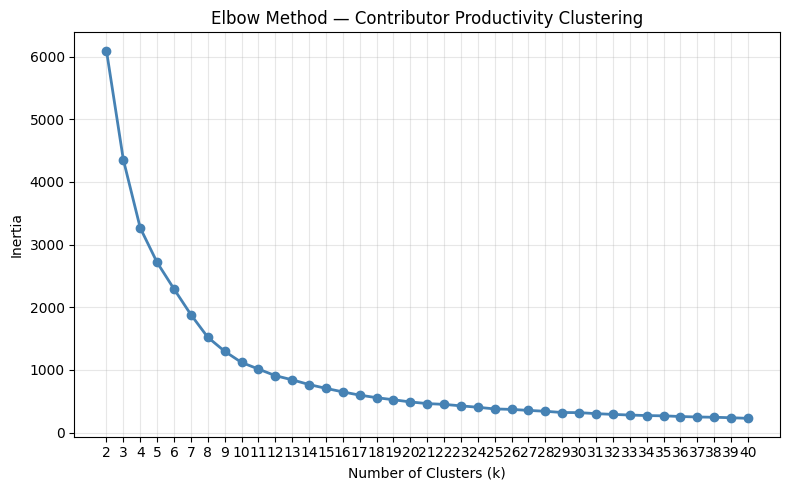

Plot saved!


In [35]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
k_range  = range(2, 41) #Apoorva

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Contributor Productivity Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_productivity.png', dpi=150)
plt.show()
print("Plot saved!")

<h5>  Silhouette Scores

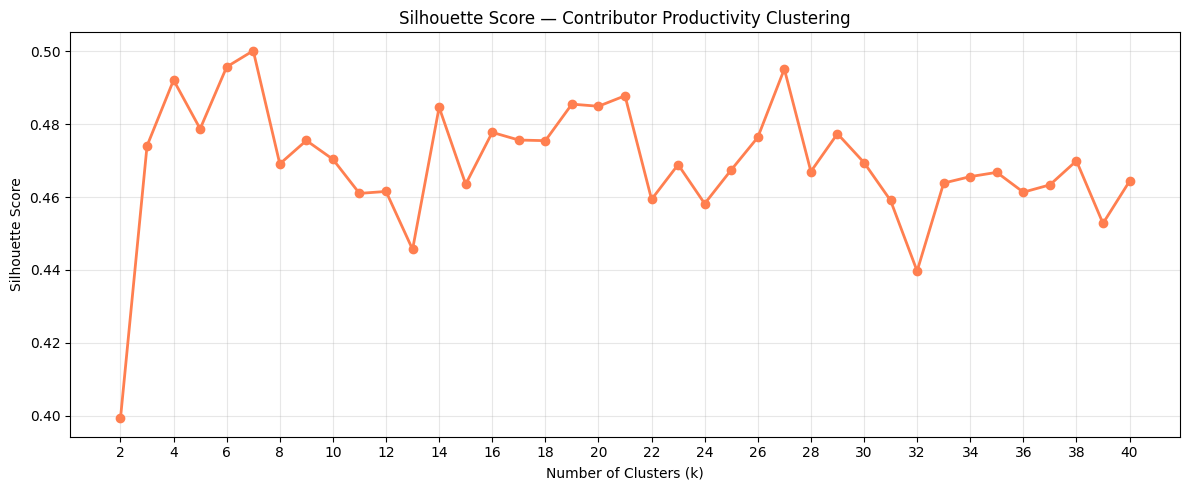


Silhouette Scores:
  k=2: 0.3993
  k=3: 0.4740
  k=4: 0.4921
  k=5: 0.4787
  k=6: 0.4957
  k=7: 0.5001
  k=8: 0.4691
  k=9: 0.4755
  k=10: 0.4703
  k=11: 0.4610
  k=12: 0.4615
  k=13: 0.4456
  k=14: 0.4846
  k=15: 0.4635
  k=16: 0.4777
  k=17: 0.4756
  k=18: 0.4755
  k=19: 0.4855
  k=20: 0.4849
  k=21: 0.4878
  k=22: 0.4593
  k=23: 0.4689
  k=24: 0.4582
  k=25: 0.4674
  k=26: 0.4764
  k=27: 0.4951
  k=28: 0.4670
  k=29: 0.4774
  k=30: 0.4695
  k=31: 0.4591
  k=32: 0.4397
  k=33: 0.4638
  k=34: 0.4656
  k=35: 0.4668
  k=36: 0.4613
  k=37: 0.4633
  k=38: 0.4699
  k=39: 0.4528
  k=40: 0.4643

Best k: 7


In [36]:
from sklearn.metrics import silhouette_score

k_range = range(2, 41)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='coral', linewidth=2)
plt.title('Silhouette Score — Contributor Productivity Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 41, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_productivity.png', dpi=150)
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k: {best_k}")

<h5> Run K-Means with k=7

In [37]:
# Run K-Means with k=7
kmeans_final = KMeans(n_clusters=7, random_state=42, n_init=10)
profiles['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(profiles['cluster'].value_counts().sort_index())

print("\nCluster profiles — mean of each feature:")
print(profiles.groupby('cluster')[features + ['productivity']].mean().round(2))

Cluster sizes:
cluster
0    392
1    869
2    108
3    191
4     22
5    125
6     89
Name: count, dtype: int64

Cluster profiles — mean of each feature:
         avg_dev_time_hrs  avg_effort_points  avg_monthly_velocity  merge_rate  productivity  productivity
cluster                                                                                                   
0                   46.35               6.81                  7.94        0.96          0.24          0.24
1                    9.40               2.70                  3.05        0.99          0.91          0.91
2                    0.26               1.08                  1.56        0.99          6.56          6.56
3                    9.13               2.53                  0.10        0.03          0.01          0.01
4                   23.34               3.77                 25.48        0.95          2.09          2.09
5                  143.05               7.89                  8.30        0.99          0.06     

In [38]:
print("\nCluster profiles — mean of each feature:")
print(profiles.groupby('cluster')[features].mean().round(2))


Cluster profiles — mean of each feature:
         avg_dev_time_hrs  avg_effort_points  avg_monthly_velocity  merge_rate  productivity
cluster                                                                                     
0                   46.35               6.81                  7.94        0.96          0.24
1                    9.40               2.70                  3.05        0.99          0.91
2                    0.26               1.08                  1.56        0.99          6.56
3                    9.13               2.53                  0.10        0.03          0.01
4                   23.34               3.77                 25.48        0.95          2.09
5                  143.05               7.89                  8.30        0.99          0.06
6                   98.08               7.85                  0.12        0.01          0.00


<h5> Apply PCA

In [39]:
from sklearn.decomposition import PCA

# Drop any existing PCA columns first
cols_to_drop = [c for c in profiles.columns if 'PC' in c or 'PCA' in c]
profiles = profiles.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {profiles.columns.tolist()}")

# Apply PCA fresh
pca        = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Add PCA1 and PCA2
profiles['PCA1'] = pca_result[:, 0]
profiles['PCA2'] = pca_result[:, 1]

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained : {pca.explained_variance_ratio_.sum():.1%}")
print(f"\nFinal columns: {profiles.columns.tolist()}")
print(profiles[['user_id', 'cluster', 'PCA1', 'PCA2']].head(10))

Dropped columns: []
Remaining columns: ['user_id', 'total_prs', 'merged_prs', 'avg_dev_time_hrs', 'avg_effort_points', 'active_months', 'merge_rate', 'total_velocity', 'avg_monthly_velocity', 'pct_feat', 'pct_fix', 'productivity', 'cluster']

Explained variance ratio: [0.448 0.283]
Total variance explained : 73.1%

Final columns: ['user_id', 'total_prs', 'merged_prs', 'avg_dev_time_hrs', 'avg_effort_points', 'active_months', 'merge_rate', 'total_velocity', 'avg_monthly_velocity', 'pct_feat', 'pct_fix', 'productivity', 'cluster', 'PCA1', 'PCA2']
   user_id  cluster      PCA1      PCA2
0       17        1 -1.832246  0.459881
1      534        1 -0.475545  0.409093
2      686        1  0.335923  0.107088
3     1472        1 -0.165607  0.568104
4     2567        3 -1.083684 -2.384617
5     2600        1 -1.530006  0.149875
6     3363        1 -0.058293  0.195614
7     3548        1 -1.361202  0.210174
8     3908        1 -1.390597  0.011286
9     4205        0  2.223298  0.478903


In [40]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
profiles = profiles.rename(columns={'cluster': 'cluster_kmeans'})
print(profiles.head(20))

    user_id  total_prs  merged_prs  avg_dev_time_hrs  avg_effort_points  active_months  merge_rate  total_velocity  avg_monthly_velocity  pct_feat   pct_fix  productivity  cluster_kmeans      PCA1      PCA2
0        17          1           1          0.368889           1.000000              1         1.0             1.0              1.000000       0.0  0.000000      2.710843               1 -1.832246  0.459881
1       534          2           2         10.169722           2.500000              1         1.0             5.0              5.000000       0.0  1.000000      0.491656               1 -0.475545  0.409093
2       686          1           1         46.167500           4.000000              1         1.0             4.0              4.000000       1.0  0.000000      0.086641               1  0.335923  0.107088
3      1472          6           6         12.339306           3.166667              3         1.0            19.0              6.333333       0.0  0.333333      0.513265  

<H5> Plot

In [41]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'browser'

fig = go.Figure()

for cluster_id in sorted(profiles['cluster_kmeans'].unique()):
    group = profiles[profiles['cluster_kmeans'] == cluster_id]
    fig.add_trace(go.Scatter(
        x=group['PCA1'],
        y=group['PCA2'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=7, opacity=0.7),
        hovertemplate=(
            f'<b>Cluster {cluster_id}</b><br>'
            'User ID: %{customdata[0]}<br>'
            'PCA1: %{x:.2f}<br>'
            'PCA2: %{y:.2f}<br>'
            'Productivity: %{customdata[1]:.2f}<br>'
            'Avg Dev Time: %{customdata[2]:.2f} hrs<br>'
            'Merge Rate: %{customdata[3]:.2f}<br>'
            '<extra></extra>'
        ),
        customdata=group[['user_id', 'productivity', 'avg_dev_time_hrs', 'merge_rate']].values
    ))

fig.update_layout(
    title=dict(text='Contributor Productivity Clusters — PCA Visualization', x=0.5),
    xaxis_title=f'PCA1',
    yaxis_title=f'PCA2',
    height=600, width=1000,
    template='plotly_white',
    legend=dict(title='Cluster')
)

fig.show()
fig.write_html('pca_productivity_clusters.html')
print("Saved as pca_productivity_clusters.html!")

Saved as pca_productivity_clusters.html!


<h5> DBSCAN Validation

In [42]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.neighbors import NearestNeighbors
import numpy as np
import plotly.io as pio

pio.renderers.default = 'browser'

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        f'K-Distance Plot (minPts=5)',
        f'K-Distance Plot (minPts=7)',
        f'K-Distance Plot (minPts=10)'
    ]
)

colors = ['steelblue', 'coral', 'seagreen']

for i, min_samples in enumerate([5, 7, 10]):

    # Compute k-distance
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(X_scaled)
    distances, _ = neighbors.kneighbors(X_scaled)

    # Distance to kth nearest neighbor sorted
    k_distances_sorted = np.sort(distances[:, -1])

    fig.add_trace(go.Scatter(
        x=list(range(len(k_distances_sorted))),
        y=k_distances_sorted,
        mode='lines',
        name=f'minPts={min_samples}',
        line=dict(color=colors[i], width=2),
        hovertemplate='Point: %{x}<br>Distance: %{y:.4f}<extra></extra>'
    ), row=1, col=i+1)

    fig.update_xaxes(title_text='Data Points (sorted)', row=1, col=i+1)
    fig.update_yaxes(title_text=f'Distance to {min_samples}th Neighbor', row=1, col=i+1)

fig.update_layout(
    title=dict(text='K-Distance Plots — Find Optimal eps for Each minPts', x=0.5),
    height=1000, width=2400,
    template='plotly_white',
    showlegend=True
)

fig.show()
fig.write_html('kdistance_plots.html')
print("Saved as kdistance_plots.html!")
print("Look for the elbow point in each plot — that value is your optimal eps")

Saved as kdistance_plots.html!
Look for the elbow point in each plot — that value is your optimal eps


<h5> Run DBSCAN with best eps

In [43]:
# Best DBSCAN — eps=0.86 for 10 clusters
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
profiles['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution:")
print(profiles['cluster_dbscan'].value_counts().sort_index())

# Compare with K-Means
print("\nK-Means vs DBSCAN comparison:")
print(pd.crosstab(
    profiles['cluster_kmeans'],
    profiles['cluster_dbscan'],
    rownames=['K-Means'],
    colnames=['DBSCAN']
))

DBSCAN cluster distribution:
cluster_dbscan
-1    219
 0    945
 1    177
 2    325
 3     32
 4     61
 5      9
 6      9
 7      9
 8      5
 9      5
Name: count, dtype: int64

K-Means vs DBSCAN comparison:
DBSCAN   -1    0    1    2   3   4   5   6   7   8   9
K-Means                                               
0        95   66    0  222   0   0   9   0   0   0   0
1        47  817    0    0   0   0   0   0   0   0   5
2        14   62    0    0  32   0   0   0   0   0   0
3        14    0  177    0   0   0   0   0   0   0   0
4        22    0    0    0   0   0   0   0   0   0   0
5        13    0    0  103   0   0   0   9   0   0   0
6        14    0    0    0   0  61   0   0   9   5   0


<h5> Save final profiles with cluster labels

In [44]:
# Drop name column — can be recreated from cluster_dbscan when needed
profiles = profiles.drop(columns=['cluster_dbscan_name'], errors='ignore')

profiles.to_parquet(
    r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\productivity_clusters.parquet",
    index=False
)

print("Saved to productivity_clusters.parquet!")
print(f"\nFinal columns: {profiles.columns.tolist()}")
print(f"Total contributors: {len(profiles)}")

Saved to productivity_clusters.parquet!

Final columns: ['user_id', 'total_prs', 'merged_prs', 'avg_dev_time_hrs', 'avg_effort_points', 'active_months', 'merge_rate', 'total_velocity', 'avg_monthly_velocity', 'pct_feat', 'pct_fix', 'productivity', 'cluster_kmeans', 'PCA1', 'PCA2', 'cluster_dbscan']
Total contributors: 1796


<h5> Visualize DBSCAN Clusters

In [45]:
dbscan_names = {
    -1: 'Noise / Outliers',
     0: 'DBSCAN Cluster 0',
     1: 'DBSCAN Cluster 1',
     2: 'DBSCAN Cluster 2',
     3: 'DBSCAN Cluster 3',
     4: 'DBSCAN Cluster 4',
     5: 'DBSCAN Cluster 5',
     6: 'DBSCAN Cluster 6',
     7: 'DBSCAN Cluster 7',
     8: 'DBSCAN Cluster 8',
     9: 'DBSCAN Cluster 9'
}

dbscan_colors = {
    'Noise / Outliers' : 'lightgrey',
    'DBSCAN Cluster 0' : 'steelblue',
    'DBSCAN Cluster 1' : 'orange',
    'DBSCAN Cluster 2' : 'crimson',
    'DBSCAN Cluster 3' : 'seagreen',
    'DBSCAN Cluster 4' : 'mediumpurple',
    'DBSCAN Cluster 5' : 'gold',
    'DBSCAN Cluster 6' : 'hotpink',
    'DBSCAN Cluster 7' : 'teal',
    'DBSCAN Cluster 8' : 'coral',
    'DBSCAN Cluster 9' : 'darkblue'
}

profiles['cluster_dbscan_name'] = profiles['cluster_dbscan'].map(dbscan_names)

fig = go.Figure()

for name in profiles['cluster_dbscan_name'].unique():
    group = profiles[profiles['cluster_dbscan_name'] == name]
    fig.add_trace(go.Scatter(
        x=group['PCA1'],
        y=group['PCA2'],
        mode='markers',
        name=name,
        marker=dict(color=dbscan_colors[name], size=7, opacity=0.7),
        hovertemplate=(
            '<b>' + name + '</b><br>'
            'User ID: %{customdata[0]}<br>'
            'PCA1: %{x:.2f}<br>'
            'PCA2: %{y:.2f}<br>'
            'Merge Rate: %{customdata[1]:.2f}<br>'
            'Productivity: %{customdata[2]:.2f}<br>'
            '<extra></extra>'
        ),
        customdata=group[['user_id', 'merge_rate', 'productivity']].values
    ))

fig.update_layout(
    title=dict(text='DBSCAN Clusters — Contributor Productivity PCA (eps=0.95, min_samples=10)', x=0.5),
    xaxis_title='PCA1',
    yaxis_title='PCA2',
    height=550, width=1000,
    template='plotly_white',
    legend=dict(title='DBSCAN Cluster')
)

fig.show()
fig.write_html('dbscan_productivity_clusters_pca.html')
print("Saved as dbscan_productivity_clusters_pca.html!")

Saved as dbscan_productivity_clusters_pca.html!


<h5> Contributor Productivity Profiles -> How Work Type Shapes Performance

In [46]:
profiles.head()

,user_id,total_prs,merged_prs,avg_dev_time_hrs,avg_effort_points,active_months,merge_rate,total_velocity,avg_monthly_velocity,pct_feat,pct_fix,productivity,cluster_kmeans,PCA1,PCA2,cluster_dbscan,cluster_dbscan_name
0,17,1,1,0.368889,1.000000,1,1.0,1.0,1.000000,0.0,0.000000,2.710843,1,-1.832246,0.459881,0,DBSCAN Cluster 0
1,534,2,2,10.169722,2.500000,1,1.0,5.0,5.000000,0.0,1.000000,0.491656,1,-0.475545,0.409093,0,DBSCAN Cluster 0
2,686,1,1,46.167500,4.000000,1,1.0,4.0,4.000000,1.0,0.000000,0.086641,1,0.335923,0.107088,0,DBSCAN Cluster 0
3,1472,6,6,12.339306,3.166667,3,1.0,19.0,6.333333,0.0,0.333333,0.513265,1,-0.165607,0.568104,0,DBSCAN Cluster 0
4,2567,1,0,2.335556,2.000000,1,0.0,0.0,0.000000,1.0,0.000000,0.000000,3,-1.083684,-2.384617,1,DBSCAN Cluster 1


In [47]:
cluster_category_df=profiles[['productivity','cluster_kmeans']].copy()

In [48]:
cluster_category_df['productivity_mean'] = cluster_category_df.groupby('cluster_kmeans')['productivity'].transform('mean')

In [49]:
mapping_df=cluster_category_df[['cluster_kmeans', 'productivity_mean']].drop_duplicates().sort_values('productivity_mean').reset_index(drop=True)

In [50]:
mapping_df['buckets']=pd.cut(
    mapping_df['productivity_mean'],
    bins=[-float('inf'),0.01,0.1,0.9, 2.1, float('inf')],
    labels=['very low', 'low', 'medium', 'high', 'very high']
)

In [51]:
mapping_df

,cluster_kmeans,productivity_mean,buckets
0,6,0.001543,very low
1,3,0.012055,low
2,5,0.063033,low
3,0,0.238383,medium
4,1,0.908856,high
5,4,2.089950,high
6,2,6.556338,very high


In [52]:
result_df=profiles.join(mapping_df[['buckets']],on='cluster_kmeans',how='left').copy()

In [53]:
result_df.head(20)

,user_id,total_prs,merged_prs,avg_dev_time_hrs,avg_effort_points,active_months,merge_rate,total_velocity,avg_monthly_velocity,pct_feat,pct_fix,productivity,cluster_kmeans,PCA1,PCA2,cluster_dbscan,cluster_dbscan_name,buckets
0,17,1,1,0.368889,1.000000,1,1.0,1.0,1.000000,0.0,0.000000,2.710843,1,-1.832246,0.459881,0,DBSCAN Cluster 0,low
1,534,2,2,10.169722,2.500000,1,1.0,5.0,5.000000,0.0,1.000000,0.491656,1,-0.475545,0.409093,0,DBSCAN Cluster 0,low
2,686,1,1,46.167500,4.000000,1,1.0,4.0,4.000000,1.0,0.000000,0.086641,1,0.335923,0.107088,0,DBSCAN Cluster 0,low
3,1472,6,6,12.339306,3.166667,3,1.0,19.0,6.333333,0.0,0.333333,0.513265,1,-0.165607,0.568104,0,DBSCAN Cluster 0,low
4,2567,1,0,2.335556,2.000000,1,0.0,0.0,0.000000,1.0,0.000000,0.000000,3,-1.083684,-2.384617,1,DBSCAN Cluster 1,medium
5,2600,1,1,0.730000,1.000000,1,1.0,1.0,1.000000,1.0,0.000000,1.369863,1,-1.530006,0.149875,0,DBSCAN Cluster 0,low
6,3363,1,1,17.288611,4.000000,1,1.0,4.0,4.000000,1.0,0.000000,0.231366,1,-0.058293,0.195614,0,DBSCAN Cluster 0,low
7,3548,2,2,1.080278,1.500000,2,1.0,3.0,1.500000,0.5,0.500000,1.388532,1,-1.361202,0.210174,0,DBSCAN Cluster 0,low
8,3908,1,1,1.292500,1.000000,1,1.0,1.0,1.000000,1.0,0.000000,0.773694,1,-1.390597,0.011286,0,DBSCAN Cluster 0,low
9,4205,1,1,89.204167,8.000000,1,1.0,8.0,8.000000,0.0,1.000000,0.089682,0,2.223298,0.478903,2,DBSCAN Cluster 2,very low


In [54]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# bucket_order = ['very low', 'low', 'medium', 'high', 'very high']

# # Count users per bucket and convert to percentage
# counts = result_df['buckets'].value_counts().reindex(bucket_order, fill_value=0)
# total_users = len(result_df)
# pct_users = (counts / total_users) * 100

# # Mean pct_feat, pct_fix, and other per bucket
# feat_means  = result_df.groupby('buckets')['pct_feat'].mean().reindex(bucket_order, fill_value=0)
# fix_means   = result_df.groupby('buckets')['pct_fix'].mean().reindex(bucket_order, fill_value=0)
# other_means = 1 - feat_means - fix_means  # remaining proportion
# other_means = other_means.clip(lower=0)   # safety clip for floating point

# # Split bar heights by 3-way ratio, scaled to % of total users
# ratio_denom   = (feat_means + fix_means + other_means).replace(0, 1)
# feat_heights  = pct_users * feat_means  / ratio_denom
# fix_heights   = pct_users * fix_means   / ratio_denom
# other_heights = pct_users * other_means / ratio_denom

# fig, ax = plt.subplots(figsize=(9, 6))
# x = np.arange(len(bucket_order))
# bar_width = 0.5

# ax.bar(x, feat_heights,  width=bar_width, color='#4C9BE8', label='pct_feat (Feature PRs)', edgecolor='white')
# ax.bar(x, fix_heights,   width=bar_width, bottom=feat_heights, color='#E85C5C', label='pct_fix (Fix PRs)', edgecolor='white')
# ax.bar(x, other_heights, width=bar_width, bottom=feat_heights + fix_heights, color='#F4C542', label='Other', edgecolor='white')

# # Annotate total percentage on top of each bar
# for i, pct in enumerate(pct_users):
#     ax.text(x[i], pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# # Annotate feat % inside the feat segment
# for i, (fh, fm) in enumerate(zip(feat_heights, feat_means)):
#     if fh > 1.5:
#         ax.text(x[i], fh / 2, f'feat\n{fm*100:.1f}%', ha='center', va='center',
#                 fontsize=9, color='white', fontweight='bold')

# # Annotate fix % inside the fix segment
# for i, (fh, xh, fm) in enumerate(zip(feat_heights, fix_heights, fix_means)):
#     if xh > 1.5:
#         ax.text(x[i], fh + xh / 2, f'fix\n{fm*100:.1f}%', ha='center', va='center',
#                 fontsize=9, color='white', fontweight='bold')

# # Annotate other % inside the other segment
# for i, (fh, xh, oh, om) in enumerate(zip(feat_heights, fix_heights, other_heights, other_means)):
#     if oh > 1.5:
#         ax.text(x[i], fh + xh + oh / 2, f'other\n{om*100:.1f}%', ha='center', va='center',
#                 fontsize=9, color='white', fontweight='bold')

# ax.set_xticks(x)
# ax.set_xticklabels([b.capitalize() for b in bucket_order], fontsize=12)
# ax.set_xlabel('Productivity Bucket', fontsize=13)
# ax.set_ylabel('Percentage of Users (%)', fontsize=13)
# ax.set_title('User Distribution by Productivity Bucket\nwith avg. Feature vs Fix PR ratio', fontsize=14, fontweight='bold')
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
# ax.legend(loc='upper right', frameon=False)
# ax.spines[['top', 'right']].set_visible(False)
# ax.set_ylim(0, pct_users.max() * 1.15)

# plt.tight_layout()
# plt.savefig('bucket_feat_fix_other_pct_labeled.png', dpi=150, bbox_inches='tight')
# plt.show()

<h5> Compute Task Type Percentages per Contributor and Merge into Profiles

In [55]:
import pandas as pd

# ── Load raw PR data ──────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")

# ── Compute pct per type per contributor ──────────────────────────
total_per_user = df.groupby('user_id')['id'].count().reset_index()
total_per_user.columns = ['user_id', 'total_for_pct']

type_counts = df.groupby(['user_id', 'type'])['id'].count().unstack(fill_value=0).reset_index()
type_counts = type_counts.merge(total_per_user, on='user_id')

# Compute pct for each type
all_types = ['feat', 'fix', 'chore', 'docs', 'refactor', 'build', 'test', 'ci', 'perf', 'style', 'other']
for t in all_types:
    if t in type_counts.columns:
        type_counts[f'pct_{t}'] = type_counts[t] / type_counts['total_for_pct']

# Keep only pct columns
pct_cols = ['user_id'] + [f'pct_{t}' for t in all_types if t in type_counts.columns]
type_pcts = type_counts[pct_cols]

# ── Drop ALL existing pct columns from result_df before merging ───
pct_cols_to_drop = [c for c in result_df.columns if c.startswith('pct_')]
result_df = result_df.drop(columns=pct_cols_to_drop)

# ── Merge fresh pct columns ───────────────────────────────────────
result_df = result_df.merge(type_pcts, on='user_id', how='left')

print(f"Pct columns added: {[c for c in result_df.columns if c.startswith('pct_')]}")
print(f"Total columns: {len(result_df.columns)}")
print(result_df.head(3))

Pct columns added: ['pct_feat', 'pct_fix', 'pct_chore', 'pct_docs', 'pct_refactor', 'pct_build', 'pct_test', 'pct_ci', 'pct_perf', 'pct_style', 'pct_other']
Total columns: 27
   user_id  total_prs  merged_prs  avg_dev_time_hrs  avg_effort_points  active_months  merge_rate  total_velocity  avg_monthly_velocity  productivity  cluster_kmeans      PCA1      PCA2  cluster_dbscan cluster_dbscan_name buckets  pct_feat  pct_fix  pct_chore  pct_docs  pct_refactor  pct_build  pct_test  pct_ci  pct_perf  pct_style  pct_other
0       17          1           1          0.368889                1.0              1         1.0             1.0                   1.0      2.710843               1 -1.832246  0.459881               0    DBSCAN Cluster 0     low       0.0      0.0        1.0       0.0           0.0        0.0       0.0     0.0       0.0        0.0        0.0
1      534          2           2         10.169722                2.5              1         1.0             5.0                   5.0

<h5> Draw interactive plots

In [56]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'browser'

bucket_order = ['very low', 'low', 'medium', 'high', 'very high']

# All task types and their colors
task_types = ['feat', 'fix', 'chore', 'docs', 'refactor', 'build', 'test', 'ci', 'perf', 'style', 'other']
colors = {
    'feat'    : '#4C9BE8',
    'fix'     : '#E85C5C',
    'chore'   : '#F4C542',
    'docs'    : '#6BCB77',
    'refactor': '#9B59B6',
    'build'   : '#E67E22',
    'test'    : '#1ABC9C',
    'ci'      : '#E91E63',
    'perf'    : '#607D8B',
    'style'   : '#FF7043',
    'other'   : '#BDBDBD'
}

# Count users per bucket as percentage
total_users = len(result_df)
counts      = result_df['buckets'].value_counts().reindex(bucket_order, fill_value=0)
pct_users   = (counts / total_users) * 100

# Mean pct per type per bucket
type_means = {}
for t in task_types:
    col = f'pct_{t}'
    if col in result_df.columns:
        type_means[t] = result_df.groupby('buckets')[col].mean().reindex(bucket_order, fill_value=0)

# Compute bar heights per type per bucket
fig = go.Figure()

cumulative = {b: 0 for b in bucket_order}

for t in task_types:
    if t not in type_means:
        continue

    means   = type_means[t]
    heights = []

    for b in bucket_order:
        ratio_denom = sum(type_means[tt][b] for tt in type_means)
        if ratio_denom == 0:
            heights.append(0)
        else:
            heights.append(pct_users[b] * means[b] / ratio_denom)

    fig.add_trace(go.Bar(
        name=t,
        x=bucket_order,
        y=heights,
        marker_color=colors[t],
        hovertemplate=(
            f'<b>{t}</b><br>'
            'Bucket: %{x}<br>'
            'Height: %{y:.1f}%<br>'
            f'Avg pct_{t}: ' + '<br>'
            '<extra></extra>'
        ),
        text=[f'{type_means[t][b]*100:.1f}%' if heights[i] > 1.5 else '' 
              for i, b in enumerate(bucket_order)],
        textposition='inside',
        textfont=dict(color='white', size=9)
    ))

# Add total % annotation on top of each bar
for i, b in enumerate(bucket_order):
    fig.add_annotation(
        x=b,
        y=pct_users[b] + 1,
        text=f'<b>{pct_users[b]:.1f}%</b>',
        showarrow=False,
        font=dict(size=12)
    )

fig.update_layout(
    barmode='stack',
    title=dict(text='User Distribution by Productivity Bucket<br>with Task Type Breakdown', x=0.5),
    xaxis_title='Productivity Bucket',
    yaxis_title='Percentage of Users (%)',
    yaxis=dict(ticksuffix='%'),
    height=600, width=1000,
    template='plotly_white',
    legend=dict(title='Task Type', x=1.02, y=1),
    xaxis=dict(ticktext=[b.capitalize() for b in bucket_order], tickvals=bucket_order)
)

fig.show()
fig.write_html('productivity_bucket_tasktype.html')
print("Saved as productivity_bucket_tasktype.html!")

Saved as productivity_bucket_tasktype.html!


<h3> Use Case 1: Effort Trend Analysis

<h5> Load and prepare data

In [57]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────────
df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")

# ── Add month column ──────────────────────────────────────────────
df['created_at'] = pd.to_datetime(df['created_at'])
df['month']      = df['created_at'].dt.to_period('M').astype(str)

print(f"Total rows : {len(df)}")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nMonths in dataset:")
print(sorted(df['month'].unique()))

Total rows : 3998
Columns    : ['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent', 'type', 'dev_time_hrs', 'size_category', 'effort_points', 'month']

Months in dataset:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06']


C:\Users\Sid\AppData\Local\Temp\ipykernel_2720\3098781969.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month']      = df['created_at'].dt.to_period('M').astype(str)


<h5> Compute monthly averages per contributor

In [58]:
# Monthly avg dev time and effort points per contributor
monthly = df.groupby(['user_id', 'month']).agg(
    avg_dev_time_hrs  = ('dev_time_hrs',  'mean'),
    avg_effort_points = ('effort_points', 'mean'),
    pr_count          = ('id',            'count')
).reset_index()

# Count active months per contributor
active_months = monthly.groupby('user_id')['month'].nunique().reset_index()
active_months.columns = ['user_id', 'active_months']

# Filter to 2+ active months
eligible_users = active_months[active_months['active_months'] >= 2]['user_id'].tolist()
monthly_filtered = monthly[monthly['user_id'].isin(eligible_users)]

print(f"Total contributors        : {df['user_id'].nunique()}")
print(f"Contributors with 2+ months: {len(eligible_users)}")
print(f"Rows in filtered dataset  : {len(monthly_filtered)}")
print(monthly_filtered.head(10))

Total contributors        : 1796
Contributors with 2+ months: 431
Rows in filtered dataset  : 1210
    user_id    month  avg_dev_time_hrs  avg_effort_points  pr_count
3      1472  2025-03          0.910556           2.000000         1
4      1472  2025-04         33.151944           4.500000         2
5      1472  2025-06          2.273796           2.666667         3
9      3548  2025-03          1.336944           1.000000         1
10     3548  2025-06          0.823611           2.000000         1
16    10137  2025-02         22.369167           8.000000         1
17    10137  2025-05          2.039167           2.000000         1
24    22350  2025-02          0.347222           1.000000         1
25    22350  2025-04          0.239167           1.000000         1
29    24063  2025-02         21.920833           8.000000         1


<h5> Interactive dropdown chart (2 metrics -> avg_dev_time_hrs -  shows how long work took AND avg_effort_points - shows what size work they took on)

In [59]:
import json
import pandas as pd

# ── Prepare data for HTML ─────────────────────────────────────────
user_map   = df[['user_id', 'user']].drop_duplicates().set_index('user_id')['user'].to_dict()
bucket_map = result_df[['user_id', 'buckets']].drop_duplicates().set_index('user_id')['buckets'].to_dict()

# Build data dict per contributor
chart_data = {}
for user_id in eligible_users:
    user_data = monthly_filtered[monthly_filtered['user_id'] == user_id].sort_values('month')
    username  = user_map.get(user_id, str(user_id))
    bucket    = bucket_map.get(user_id, 'unknown')

    chart_data[str(user_id)] = {
        'username' : username,
        'bucket'   : bucket,
        'months'   : user_data['month'].tolist(),
        'dev_time' : user_data['avg_dev_time_hrs'].round(2).tolist(),
        'effort'   : user_data['avg_effort_points'].round(2).tolist()
    }

# Save HTML
html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Effort Trend Analysis</title>
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist@2.27.0/plotly.min.js"></script>
<style>
  body {{ font-family: Arial, sans-serif; background: #f9f9f9; margin: 0; padding: 20px; }}
  .header {{ text-align: center; margin-bottom: 20px; }}
  .header h2 {{ color: #2C2C2A; font-size: 20px; margin: 0; }}
  .header p {{ color: #888780; font-size: 13px; margin: 4px 0 0; }}
  .controls {{ display: flex; align-items: center; gap: 12px; margin-bottom: 16px; padding: 0 20px; }}
  .controls label {{ font-size: 13px; color: #5F5E5A; }}
  .controls select {{
    font-size: 13px; padding: 6px 12px;
    border: 1px solid #B4B2A9; border-radius: 6px;
    background: white; color: #2C2C2A; cursor: pointer;
    min-width: 200px;
  }}
  .badge {{
    padding: 5px 14px; border-radius: 20px;
    font-size: 12px; font-weight: 600; letter-spacing: 0.3px;
  }}
  .badge.very-low  {{ background: #FCEBEB; color: #A32D2D; }}
  .badge.low       {{ background: #FAEEDA; color: #854F0B; }}
  .badge.medium    {{ background: #FAEEDA; color: #BA7517; }}
  .badge.high      {{ background: #EAF3DE; color: #3B6D11; }}
  .badge.very-high {{ background: #E6F1FB; color: #185FA5; }}
  .badge.unknown   {{ background: #F1EFE8; color: #5F5E5A; }}
  #chart {{ background: white; border-radius: 8px; border: 1px solid #e0e0e0; }}
</style>
</head>
<body>

<div class="header">
  <h2>Effort Trend — Individual Contributor View</h2>
  <p>Avg Dev Time and Avg Effort Points per month · Contributors active 2+ months</p>
</div>

<div class="controls">
  <label>Select Contributor:</label>
  <select id="userSelect" onchange="updateChart()">
  </select>
  <span class="badge unknown" id="bucketBadge">—</span>
</div>

<div id="chart"></div>

<script>
const data = {json.dumps(chart_data)};

const bucketClass = {{
  'very low' : 'very-low',
  'low'      : 'low',
  'medium'   : 'medium',
  'high'     : 'high',
  'very high': 'very-high'
}};

// Populate dropdown
const select = document.getElementById('userSelect');
Object.entries(data).forEach(([uid, d]) => {{
  const opt = document.createElement('option');
  opt.value = uid;
  opt.text  = `${{d.username}} (${{d.bucket.charAt(0).toUpperCase() + d.bucket.slice(1)}})`;
  select.appendChild(opt);
}});

function updateChart() {{
  const uid  = select.value;
  const d    = data[uid];

  // Update badge
  const badge = document.getElementById('bucketBadge');
  badge.className = 'badge ' + (bucketClass[d.bucket] || 'unknown');
  badge.textContent = d.bucket.charAt(0).toUpperCase() + d.bucket.slice(1) + ' Productivity';

  // Build traces
  const trace1 = {{
    x: d.months, y: d.dev_time,
    mode: 'lines+markers',
    name: 'Avg Dev Time (hrs)',
    line: {{ color: 'steelblue', width: 2 }},
    marker: {{ size: 8, color: 'steelblue' }},
    yaxis: 'y1',
    hovertemplate: '<b>' + d.username + '</b><br>Month: %{{x}}<br>Avg Dev Time: %{{y:.2f}} hrs<extra></extra>'
  }};

  const trace2 = {{
    x: d.months, y: d.effort,
    mode: 'lines+markers',
    name: 'Avg Effort Points',
    line: {{ color: 'coral', width: 2, dash: 'dash' }},
    marker: {{ size: 8, color: 'coral' }},
    yaxis: 'y2',
    hovertemplate: '<b>' + d.username + '</b><br>Month: %{{x}}<br>Avg Effort Points: %{{y:.2f}}<extra></extra>'
  }};

  const layout = {{
    title: {{ text: 'Effort Trend — ' + d.username + ' | ' + d.bucket.charAt(0).toUpperCase() + d.bucket.slice(1) + ' Productivity', x: 0.5, font: {{ size: 15 }} }},
    xaxis: {{ title: 'Month', type: 'category' }},
    yaxis: {{
      title: {{ text: 'Avg Dev Time (hrs)', font: {{ color: 'steelblue' }} }},
      tickfont: {{ color: 'steelblue' }}
    }},
    yaxis2: {{
      title: {{ text: 'Avg Effort Points', font: {{ color: 'coral' }} }},
      tickfont: {{ color: 'coral' }},
      overlaying: 'y', side: 'right'
    }},
    height: 480,
    template: 'plotly_white',
    legend: {{ x: 1.08, y: 1 }},
    margin: {{ t: 60, l: 70, r: 80, b: 60 }}
  }};

  Plotly.react('chart', [trace1, trace2], layout);
}}

// Initial render
updateChart();
</script>
</body>
</html>"""

with open('effort_trend_dropdown.html', 'w') as f:
    f.write(html)

print("Saved as effort_trend_dropdown.html!")

Saved as effort_trend_dropdown.html!


In [60]:
import pandas as pd

df = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")
print("Rows (PRs):", len(df))
print("Task types:", df['type'].nunique(), "→", sorted(df['type'].unique()))
print("Contributors:", df['user_id'].nunique())

Rows (PRs): 3998
Task types: 11 → ['build', 'chore', 'ci', 'docs', 'feat', 'fix', 'other', 'perf', 'refactor', 'style', 'test']
Contributors: 1796


In [61]:
import pandas as pd

# Original joined dataset
df_orig = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\joined_dataset.parquet")

# Final cleaned
df_clean = pd.read_parquet(r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet\final_effort_point_clean_dataset.parquet")

print("Original rows:", len(df_orig))
print("Final rows:   ", len(df_clean))
print("Dropped:      ", len(df_orig) - len(df_clean))
print("% retained:   ", f"{len(df_clean)/len(df_orig)*100:.1f}%")

Original rows: 6618
Final rows:    3998
Dropped:       2620
% retained:    60.4%


In [62]:
import pandas as pd

base = r"C:\SID\Apoorva\Project\504_Project_AI_for_SW\dataset_parquet"

orig     = len(pd.read_parquet(f"{base}\\joined_dataset.parquet"))
closed   = len(pd.read_parquet(f"{base}\\closed_prs_dataset.parquet"))
no_inst  = len(pd.read_parquet(f"{base}\\instant_close_drop_prs_clean_dataset.parquet"))
no_bots  = len(pd.read_parquet(f"{base}\\no_bots_clean_dataset.parquet"))
no_dups  = len(pd.read_parquet(f"{base}\\no_duplicates_user&_title_clean_dataset.parquet"))
final    = len(pd.read_parquet(f"{base}\\final_effort_point_clean_dataset.parquet"))

print(f"Original:               {orig}")
print(f"After drop open PRs:    {closed}   (-{orig-closed})")
print(f"After drop ≤5 min:      {no_inst}  (-{closed-no_inst})")
print(f"After drop bots:        {no_bots}  (-{no_inst-no_bots})")
print(f"After drop duplicates:  {no_dups}  (-{no_bots-no_dups})")
print(f"After IQR cleaning:     {final}   (-{no_dups-final})")
print(f"\nTotal dropped: {orig-final} ({(orig-final)/orig*100:.1f}%)")

Original:               6618
After drop open PRs:    6149   (-469)
After drop ≤5 min:      5464  (-685)
After drop bots:        4709  (-755)
After drop duplicates:  4645  (-64)
After IQR cleaning:     3998   (-647)

Total dropped: 2620 (39.6%)
